In [3]:
import pandas as pd

df = pd.read_csv('sales_data_sample.csv', encoding='latin1')

df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [4]:
df = df[['MONTH_ID', 'YEAR_ID', 'SALES']]
df.head()

,MONTH_ID,YEAR_ID,SALES
0,2,2003,2871.00
1,5,2003,2765.90
2,7,2003,3884.34
3,8,2003,3746.70
4,10,2003,5205.27


In [5]:
df_grouped = df.groupby(['YEAR_ID', 'MONTH_ID'])['SALES'].sum().reset_index()
df_grouped.head()

,YEAR_ID,MONTH_ID,SALES
0,2003,1,129753.60
1,2003,2,140836.19
2,2003,3,174504.90
3,2003,4,201609.55
4,2003,5,192673.11


In [7]:
df_grouped['Time'] = range(1, len(df_grouped)+1)
from sklearn.linear_model import LinearRegression

X = df_grouped[['Time']]
y = df_grouped['SALES']

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [9]:
future = pd.DataFrame({'Time': [len(df_grouped)+1,
                               len(df_grouped)+2,
                               len(df_grouped)+3]})

predictions = model.predict(future)

print("Future Sales:", predictions)

Future Sales: [494989.23135468 504924.99884729 514860.7663399 ]


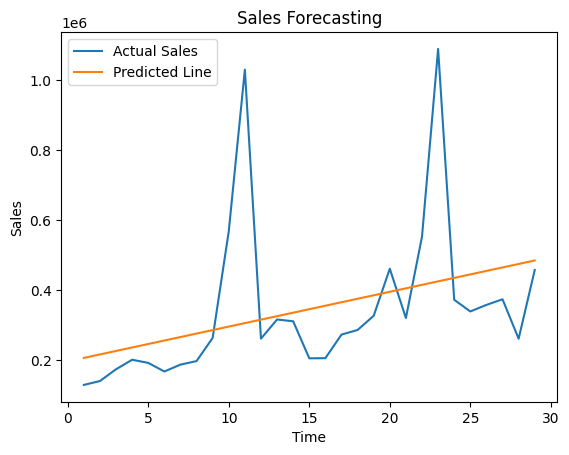

In [10]:
import matplotlib.pyplot as plt

plt.plot(df_grouped['Time'], df_grouped['SALES'], label='Actual Sales')
plt.plot(df_grouped['Time'], model.predict(X), label='Predicted Line')

plt.xlabel("Time")
plt.ylabel("Sales")
plt.title("Sales Forecasting")
plt.legend()

plt.show()